# LSTM для классификации спама

Обучение BiLSTM на том же датасете, что и классический ML.
Цель: сравнить с TF-IDF + LogReg/RF/SVC/XGBoost.

In [4]:
import re, string, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, f1_score

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, Dense, Dropout,
                                     SpatialDropout1D, Bidirectional)
from tensorflow.keras.callbacks import EarlyStopping

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

print("TF version:", tf.__version__)

TF version: 2.20.0


### Загрузка датасета

In [6]:
df = pd.read_csv("emails.csv")
print(df.shape)
df.head(2)

(5728, 2)


,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1


### Очистка датасета

In [7]:
LEMMATIZER = WordNetLemmatizer()
STOP_WORDS = set(stopwords.words('english'))
FIRST_N_SKIP = 9

def clean_text(text):
    text = text[FIRST_N_SKIP:].lower()
    text = "".join(ch for ch in text if ch not in string.punctuation)
    tokens = text.split()
    clean_tokens = [LEMMATIZER.lemmatize(w) for w in tokens if w not in STOP_WORDS]
    return " ".join(clean_tokens)

df['clean_text'] = df['text'].apply(clean_text)
print("ДО:  ", df['text'].iloc[0][:200])
print("ПОСЛЕ:", df['clean_text'].iloc[0][:200])

ДО:   Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is full of suqgestions and the information isoverwhelminq ; but a good  catchy logo , st
ПОСЛЕ: naturally irresistible corporate identity lt really hard recollect company market full suqgestions information isoverwhelminq good catchy logo stylish statlonery outstanding website make task much eas


### Разбиение на выборки

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['spam'],
    test_size=0.2, random_state=42, stratify=df['spam']
)
print(X_train.shape, X_test.shape)
print("Disbalance train:", (y_train==0).sum() / (y_train==1).sum())

(4582,) (1146,)
Disbalance train: 3.1882998171846437


### Токенизация

In [9]:
MAX_WORDS = 10000
MAX_LEN = 500

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(
    tokenizer.texts_to_sequences(X_train),
    maxlen=MAX_LEN, padding='pre', truncating='post'
)
X_test_seq = pad_sequences(
    tokenizer.texts_to_sequences(X_test),
    maxlen=MAX_LEN, padding='pre', truncating='post'
)
print("Train:", X_train_seq.shape, "Test:", X_test_seq.shape)

Train: (4582, 500) Test: (1146, 500)


### Модель

In [10]:
model = Sequential([
    Embedding(MAX_WORDS, 128, input_length=MAX_LEN),
    SpatialDropout1D(0.4),
    Bidirectional(LSTM(64, dropout=0.4, return_sequences=False)),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid'),
])
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Обучение

In [11]:
es = EarlyStopping(monitor='val_loss', patience=3,
                   restore_best_weights=True, verbose=1)

history = model.fit(
    X_train_seq, y_train,
    epochs=15, batch_size=64,
    validation_split=0.2,
    callbacks=[es],
    verbose=1,
)

Epoch 1/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 46s 742ms/step - accuracy: 0.8374 - loss: 0.3885 - val_accuracy: 0.9575 - val_loss: 0.1212
Epoch 2/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 42s 720ms/step - accuracy: 0.9700 - loss: 0.0886 - val_accuracy: 0.9847 - val_loss: 0.0430
Epoch 3/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 43s 740ms/step - accuracy: 0.9924 - loss: 0.0222 - val_accuracy: 0.9924 - val_loss: 0.0334
Epoch 4/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 41s 709ms/step - accuracy: 0.9932 - loss: 0.0215 - val_accuracy: 0.9935 - val_loss: 0.0304
Epoch 5/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 42s 719ms/step - accuracy: 0.9965 - loss: 0.0125 - val_accuracy: 0.9891 - val_loss: 0.0590
Epoch 6/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 42s 721ms/step - accuracy: 0.9978 - loss: 0.0059 - val_accuracy: 0.9891 - val_loss: 0.0865
Epoch 7/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 83s 747ms/step - accuracy: 0.9978 - loss: 0.0089 - val_accuracy: 0.9935 - val_loss: 0.0260
Epoch 8/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 81s 729ms/step - accuracy: 0.9992 - loss: 0.0039 - val_accu

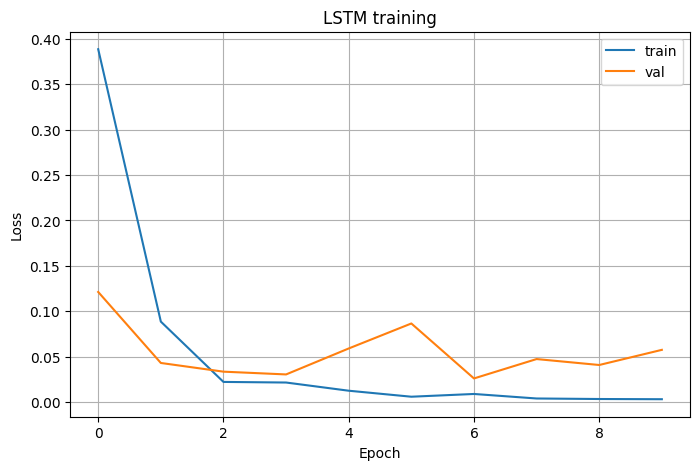

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('LSTM training'); plt.legend(); plt.grid(True)
plt.show()

### Метрики

In [13]:
y_proba = model.predict(X_test_seq).ravel()
y_pred = (y_proba > 0.5).astype(int)

print(classification_report(y_test, y_pred, digits=4))
print(f"F1 (spam): {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")

36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step
              precision    recall  f1-score   support

           0     0.9931    0.9908    0.9920       872
           1     0.9710    0.9781    0.9745       274

    accuracy                         0.9878      1146
   macro avg     0.9821    0.9845    0.9833      1146
weighted avg     0.9878    0.9878    0.9878      1146

F1 (spam): 0.9745
ROC-AUC:   0.9984


In [14]:
model.save("lstm_spam.keras")
with open("tokenizer_config.json", "w", encoding="utf-8") as f:
    f.write(tokenizer.to_json())

from google.colab import files
files.download("lstm_spam.keras")
files.download("tokenizer_config.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>